In [1]:
import numpy as np
import numpyro.distributions as dist
from numpyro.distributions import constraints

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
matplotlib.rc('image', cmap='gray', interpolation='none', origin='lower')

import jax.numpy as jnp
from jax import random, jit
import jax


import pandas as pd
from scipy.stats import gaussian_kde as kde
from scipy.stats import norm

# import scarlet
import scarlet2
# from scarlet.display import AsinhMapping,AsinhPercentileNorm,show_scarlet2_scene,LinearPercentileNorm
# from scarlet.source import StaticSource,MultiExtendedSource, StaticMultiExtendedSource
from scarlet2 import *
from scarlet2 import relative_step
from scarlet2 import (
    Observation, Frame, Scene, Source, PointSource,
    init, relative_step, Parameter, StaticArraySpectrum, 
    TransientArraySpectrum
)
from scarlet2 import Starlet
from scarlet2.plot import AsinhPercentileNorm


import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.wcs import WCS
from astropy.io import fits
import astropy.io.fits as fits

import sys
import copy
import corner
import h5py
import os
import glob
import sep
from sep import Background, extract
import tarfile
import equinox as eqx
# import distrax
import optax
from tqdm.auto import tqdm
# import cmasher as cmr


from functools import partial
from skimage import draw
%matplotlib inline
# import astrophot as ap
pixelscale=0.17


/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load the Data + Define Observation and Frame: 
#### Get Rubin + 2 Roman data
get files and psfs, based on RubinRoman_TD-lc.ipynb \\

In [2]:
# ============================================================================
# 1. General File
# ============================================================================
img_index = 1952
t_start = 56180   #start epoch I think? #mjdstart in rubinromanTD notebook
# times = np.arange(56150,56350,2)
t_off   = 56150
t_on    = 56200

times = [56150, 56160, 56170, 56180, 56190, 56200, 56210, 56210, 56220, 56230, 56240, 56250]
# times = np.arange(56150,56250,2)
# times = [56150, 56200]
epochs = [str(i) for i in range(len(times))] # basically just list of index keys correspond to each time?

path = '/scratch/network/vk9342/lenstronomy-tutorials/Notebooks/JP_spring_2025_modified_code/outputs/SNsims_TD_noise/'
data_path  = path + 'img_' + str(img_index) + '/'
psf_path   = '/scratch/network/vk9342/lenstronomy-tutorials/Notebooks/JP_spring_2025_modified_code/'

bands     = ["g","r","i"]
BANDS = ['G', 'R', 'I']
bandall = ['g','r','i','G','R','I']

channels = []
channels_on = []
observations = []
epochs_on = []

n_lsst  = len(bands) * len(times)   # e.g. 3 bands × (len(times) you picked)
n_roman  = len(BANDS) * 2   # 3 bands × 2 epochs = 6


In [3]:
# ============================================================================
# 2. PSF File paths for low Res Rubin
# ============================================================================
psf_lsst_data  = fits.open(psf_path+'psf_LSST.fits')[0].data.astype('float32')     
Np1, Np2        = psf_lsst_data.shape
psf_lsst_      = jnp.asarray([psf_lsst_data])  #jnp.asarray([psf_lsst_data,psf_lsst_data,psf_lsst_data])
psf_lsst       = scarlet2.ArrayPSF(psf_lsst_)

In [4]:
# ============================================================================
# 3. Load Observations for each Rubin epoch
# ============================================================================
for band in bands:
    for ind, epoch in enumerate(times):
        channel_sc2 = (band, str(ind)) 
        # save epoch ind corresponding to Roman images to append to channels later 
        if epoch == t_on:
            ind_t_on = str(ind)
        elif epoch == t_off:
            ind_t_off = str(ind)
        
        # get channels for only 'on' times
        if epoch >= t_start and epoch<t_start+400:  #Why 400 specifically?
            channels_on.append(channel_sc2)
            epochs_on.append(ind)
        
        #image files
        data_file_name = 'image_LSST_'+band+'_'+str(img_index)+'_newSN_'+str(epoch)+'.fits' #is this pre psf data?
        img = data_path+ data_file_name

        obs_hdu = fits.open(img)
        data_lsst = obs_hdu[0].data
        N1, N2 = data_lsst.shape
        data_lsst = data_lsst.reshape(1, N1, N2) #reshape because?
        obs_hduw = fits.open(os.path.join(data_path, 'image_LSST_'+band+'_wcs_'+str(img_index)+'_newSN_'+str(epoch)+'.fits')) # is this post psf data?
        wcs_lsst = WCS(obs_hduw[0].header)
        data_lsst = jnp.array(np.asfarray(data_lsst).byteswap().newbyteorder(), jnp.float32) 

        #What should my weights be???????
        obs_lsst = scarlet2.Observation(data_lsst,
                                      wcs=wcs_lsst,
                                      psf=psf_lsst,
                                      channels=[channel_sc2],
                                      weights=None)
        observations.append(obs_lsst)

        channels.append(channel_sc2)


In [5]:
# ============================================================================
# 4. PSF file paths for high Res Roman
# ============================================================================
psf_roman = fits.open(psf_path + "psf_Roman.fits")[0].data.astype('float32')  
psf_roman = jnp.array(psf_roman, jnp.float32)

psf_roman_single = jnp.asarray([psf_roman]) 
psf_roman_single  = scarlet2.ArrayPSF(psf_roman_single)

psf_roman_ = jnp.asarray([psf_roman])  #jnp.asarray([psf_roman,psf_roman,psf_roman])
# Why line below for roman psf, but not rubin?
psf_roman_ = (psf_roman_-np.min(psf_roman_))/(np.max(psf_roman_)-np.min(psf_roman_)) 
psf_roman = scarlet2.ArrayPSF(psf_roman_)


In [6]:
# ============================================================================
# 5. Load high-res off/on images for Roman
# ============================================================================

t_on    = 56200
t_off   = 56150

#Read in a single epoch of high resolution imaging WITHOUT the SN
for band, BAND in zip(bands, BANDS):
    # Load the HST image data
    channel_sc2 = (BAND, ind_t_off)
    
    roman_hdu = fits.open(os.path.join(data_path, "image_Roman_"+band+"_"+str(img_index)+"_newSN_"+str(t_off)+".fits"))
    data_roman = roman_hdu[0].data
    N1, N2 = data_roman.shape
    data_roman = data_roman.reshape(1, N1, N2)
    roman_hdu = fits.open(os.path.join(data_path, "image_Roman_"+band+"_wcs_"+str(img_index)+"_newSN_"+str(t_off)+".fits"))
    wcs_roman = WCS(roman_hdu[0].header)
    
    
    data_roman_offSN = jnp.array(np.asfarray(data_roman).byteswap().newbyteorder(), jnp.float32)
    # Scale the HST data
    n,n1, n2 = jnp.shape(data_roman)
    #data_hst *= data_hsc.max() / data_hst.max()
    N,N1, N2 = data_roman.shape

    # define two observation packages and match to frame
    obs_roman_offSN = scarlet2.Observation(data_roman,
                                   wcs=wcs_roman,
                                   psf=psf_roman,
                                   channels=[channel_sc2],
                                   weights=None) #should weights be none?    
    
    channels.append(channel_sc2)
    observations.append(obs_roman_offSN)



#Read in a single epoch of high resolution imaging WITH the SN
for band, BAND in zip(bands, BANDS):

    channel_sc2 = (BAND, ind_t_on)
    
    roman_hdu = fits.open(os.path.join(data_path, "image_Roman_"+band+"_"+str(img_index)+"_newSN_"+str(t_on)+".fits"))
    data_roman = roman_hdu[0].data
    N1, N2 = data_roman.shape
    data_roman = data_roman.reshape(1, N1, N2)
    roman_hdu = fits.open(os.path.join(data_path, "image_Roman_"+band+"_wcs_"+str(img_index)+"_newSN_"+str(t_off)+".fits"))  
    wcs_roman = WCS(roman_hdu[0].header)
    print(wcs_roman)
    data_roman = jnp.array(np.asfarray(data_roman).byteswap().newbyteorder(), jnp.float32)
    # Load the HST PSF data
    
    
    if float(epoch)>t_start and float(epoch)<t_start+400:
        channels_on.append(channel_sc2)

    # define two observation packages and match to frame
    obs_roman_postSN = scarlet2.Observation(data_roman,
                                   wcs=wcs_roman,
                                   psf=psf_roman,
                                   channels=[channel_sc2],
                                   weights=None) #should weights be none? 
    
    channels.append(channel_sc2)
    observations.append(obs_roman_postSN)


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 2.0 28.0 
CD1_1 CD1_2  : -3.0555555555555e-05 -0.0 
CD2_1 CD2_2  : 0.0 3.05555555555555e-05 
NAXIS : 55  55
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 2.0 28.0 
CD1_1 CD1_2  : -3.0555555555555e-05 -0.0 
CD2_1 CD2_2  : 0.0 3.05555555555555e-05 
NAXIS : 55  55
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 0.0 0.0 
CRPIX : 2.0 28.0 
CD1_1 CD1_2  : -3.0555555555555e-05 -0.0 
CD2_1 CD2_2  : 0.0 3.05555555555555e-05 
NAXIS : 55  55


In [7]:
#How many observations did we end up reading in? Should be at least a few
print(len(observations))

42


In [8]:
# ============================================================================
# 6. Make Frame and match observations
# ============================================================================
model_frame_psf = scarlet2.GaussianPSF(0.7)
model_frame = scarlet2.Frame.from_observations(
    observations=observations,
    coverage="union",  # or "intersection"
)
for obs in observations:
    obs.match(model_frame)

### Find Sources

In [9]:
# ============================================================================
# 7. Find sourced in image - from RubinRoman_TD notebook
# ============================================================================

def makeCatalog(observations, lvl=3, wave=True, SNR=2.0):
    
    normed_images = np.asarray([obs.data[0] for obs in observations])
    interps = normed_images
    
    interps = np.asarray(interps/np.sum(interps))
    detect_image = np.sum(interps,axis=(0))
    # Wavelet transform
    # wave_detect = scarlet.Starlet.from_image(detect_image).coefficients
    wave_detect = Starlet.from_image(detect_image).coefficients

    if wave:
        # Creates detection from the first 3 wavelet levels
        detect = wave_detect[:lvl,:,:].sum(axis = 0)
    else:
        detect = detect_image

    detect = np.array(detect)

        # Runs SEP detection
    bkg = sep.Background(detect)
    catalog = sep.extract(detect-bkg.globalback, SNR, err=bkg.globalrms)
    background=[]
    bg_rms=[]
    for ind in range(len(observations)):
        img = np.asfarray(observations[ind].data)
        if np.size(img.shape) == 3:
            bg_rms.append(np.array([sep.Background(band).globalrms for band in img]))
            background.append(np.array([sep.Background(band).globalback for band in img]))
        else:
            bg_rms.append(sep.Background(img).globalrms)
            background.append(sep.Background(img).globalback)
    return catalog, bg_rms, detect_image, background

In [10]:
# ============================================================================
# 8. Find sources in image - from RubinRoman_TD notebook
# USE ROMAN IMAGES ONLY
# ============================================================================

#If the source detection is not finding all the sources, you can first try to adjust these three parameters to help it find the sources
lvl=1
wave=2
SNR=2.0

lsst_obs = observations[:-n_roman]
roman_obs = observations[-n_roman:]

observations_sc2=[]
normsingle=[]

# ============================================================================   
# DETECT SOURCES BASED ONLY ON ROMAN IMGS
catalog_single_roman, bgsingle_roman, detectsingle_roman, globalback_roman = makeCatalog(roman_obs, lvl, wave)
pixel = np.stack((catalog_single_roman['y'], catalog_single_roman['x']), axis=1)
ra_dec = pixel
print(ra_dec.shape)
# ============================================================================

(3, 2)


In [11]:
#################################################################################
### MAKE observations_sc2 ###########################
bgarr_roman     = np.asfarray(bgsingle_roman)
bgarrall_roman  = np.hstack((bgarr_roman.flatten(),np.asfarray(bgsingle_roman).flatten()))
bgarr_roman     = np.asfarray(bgsingle_roman)
print(bgarrall_roman.shape)

catalog_single_lsst, bgsingle_lsst, detectsingle_lsst, globalback_lsst = makeCatalog(lsst_obs, lvl, wave)
bgarr_lsst    = np.asfarray(bgsingle_lsst)
bgarrall_lsst = np.hstack((bgarr_lsst.flatten(),np.asfarray(bgsingle_lsst).flatten()))
bgarr_lsst    = np.asfarray(bgsingle_lsst)
print(bgarrall_lsst.shape)


bgr_lsst = np.array([b[0] for b in bgarr_lsst])
bgr_roman = np.array([b[0] for b in bgarr_roman])
bgarr_all = np.concatenate([bgr_lsst, bgr_roman], axis=0)

gb_lsst = np.array([b[0] for b in globalback_lsst])
gb_roman = np.array([b[0] for b in globalback_roman])
globalback_all = np.concatenate([gb_lsst, gb_roman], axis=0)

print(len(bgarr_all))
print(len(globalback_all))


for ind,(obs2, bg, back) in enumerate(zip(observations, bgarr_all, globalback_all)):

    print(ind)
    
    w = obs2.frame.wcs
    psf = obs2.frame.psf
    weights2=np.ones(obs2.data.shape) / (10*bg**2)#[:, None, None]  #??in RubinRoman notebook insteads of bg it uses bgarr_all, is this a typo?
    data = obs2.data-back   #Subtract background flux

    print(channels[ind])
    
    obs_sc2 = scarlet2.Observation(jnp.asarray(data), jnp.asarray(weights2), psf=psf,channels=[channels[ind]],wcs=w)
    observations_sc2.append(obs_sc2)
    
    #Store norm based on observation data
    normsingle.append(
        AsinhPercentileNorm(
            jnp.asarray(np.asarray((obs2.data[:,10:-10,10:-10]),dtype=np.float32)),
            percentiles=[0.001, 50, 80])
    )


# # ============================================================================   
# # obssinglearr=np.asarray(observations) --> not used anywhere?
# bgarr_roman     = np.asfarray(bgsingle_roman)
# bgarrall_roman  = np.hstack((bgarr_roman.flatten(),np.asfarray(bgsingle_roman).flatten()))
# bgarr_roman     = np.asfarray(bgsingle_roman)
# print(bgarrall_roman.shape)

# normsingle=[]

# for ind,(obs2,bg,back) in enumerate(zip(roman_obs,bgarr_roman,globalback_roman)):
#     w = obs2.frame.wcs
#     weights2=np.ones(obs2.data.shape) / (10*bgarr_roman**2)[:, None, None]
#     #Subtract background flux
#     data = obs2.data-back
    
#     obs_sc2 = scarlet2.Observation(jnp.asarray(data), jnp.asarray(weights2), psf=psf_roman,channels=[channels[ind]],wcs=w)
#     observations_sc2.append(obs_sc2)
    
#     #Store norm based on observation data
#     normsingle.append(
#         AsinhPercentileNorm(
#             jnp.asarray(np.asarray((obs2.data[:,10:-10,10:-10]),dtype=np.float32)),
#             percentiles=[0.001, 50, 80])
#     )
#     ## the 50 above is random, it gave an error asking for a third number



(12,)
(72,)
42
42
0
('g', '0')
1
('g', '1')
2
('g', '2')
3
('g', '3')
4
('g', '4')
5
('g', '5')
6
('g', '6')
7
('g', '7')
8
('g', '8')
9
('g', '9')
10
('g', '10')
11
('g', '11')
12
('r', '0')
13
('r', '1')
14
('r', '2')
15
('r', '3')
16
('r', '4')
17
('r', '5')
18
('r', '6')
19
('r', '7')
20
('r', '8')
21
('r', '9')
22
('r', '10')
23
('r', '11')
24
('i', '0')
25
('i', '1')
26
('i', '2')
27
('i', '3')
28
('i', '4')
29
('i', '5')
30
('i', '6')
31
('i', '7')
32
('i', '8')
33
('i', '9')
34
('i', '10')
35
('i', '11')
36
('G', '0')
37
('R', '0')
38
('I', '0')
39
('G', '5')
40
('R', '5')
41
('I', '5')


In [12]:
model_frame = scarlet2.Frame.from_observations(
    observations=observations_sc2,
    coverage="union",  # or "intersection"
)
for obs in observations_sc2:
    obs.match(model_frame)

### Initialize Sources

In [13]:
# ============================================================================
# 10. Source initialization
# ============================================================================
lsst_obs_sc2 = observations_sc2[:-n_roman]
roman_obs_sc2 = observations_sc2[-n_roman:]

band_selector  = lambda ch: ch[0]
epoch_selector = lambda ch: ch[1]


In [14]:
# ============================================================================
# 9. Get and visualize sources in image
# ============================================================================
world_coords = []
for y, x in ra_dec:
    sky = wcs_roman.pixel_to_world(x, y)   # note: pixel_to_world(x, y)
    world_coords.append(SkyCoord(sky.ra, sky.dec))

roman_pixel_coords = [wcs_roman.world_to_pixel(sky) for sky in world_coords]
lsst_pixel_coords = [wcs_lsst.world_to_pixel(sky) for sky in world_coords]

## Ra and dec centers from SEP catalog
sky_coords = world_coords

In [15]:
print("Detected source pixel coordinates:")
for i, (y, x) in enumerate(ra_dec, start=1):
    print(f"  Source {i:>2d}: x = {x:.2f}, y = {y:.2f}")

print("\nDetected source sky coordinates:")
for i, sky in enumerate(world_coords, start=1):
    # in decimal degrees:
    print(f"  Source {i:>2d}: RA = {sky.ra.deg:.6f}°,  Dec = {sky.dec.deg:.6f}°")

print("\nBack to LSST pixel coords:")
for i, (x_lsst, y_lsst) in enumerate(lsst_pixel_coords, start=1):
    print(f" Source {i}:  x = {x_lsst:.2f},  y = {y_lsst:.2f}")

print("\nBack to Roman pixel coords:")
for i, (x_roman, y_roman) in enumerate(roman_pixel_coords, start=1):
    print(f" Source {i}:  x = {x_roman:.2f},  y = {y_roman:.2f}")


Detected source pixel coordinates:
  Source  1: x = 19.02, y = 25.95
  Source  2: x = 26.32, y = 26.86
  Source  3: x = 31.07, y = 27.88

Detected source sky coordinates:
  Source  1: RA = 359.999449°,  Dec = -0.000032°
  Source  2: RA = 359.999226°,  Dec = -0.000004°
  Source  3: RA = 359.999081°,  Dec = 0.000027°

Back to LSST pixel coords:
 Source 1:  x = 10.91,  y = 14.42
 Source 2:  x = 14.93,  y = 14.92
 Source 3:  x = 17.54,  y = 15.49

Back to Roman pixel coords:
 Source 1:  x = 19.02,  y = 25.95
 Source 2:  x = 26.32,  y = 26.86
 Source 3:  x = 31.07,  y = 27.88


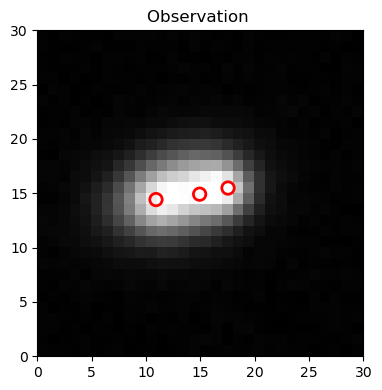

In [16]:
# draw the observation into the current axes
lsst_obs_sc2 = observations_sc2[:-n_roman]
roman_obs_sc2 = observations_sc2[-n_roman:]


scarlet2.plot.observation(
    observation=observations[1],
    norm=None,
    channel_map=None,
    show_psf=False,
    add_labels=False,
)

# # grab the current axes
ax = plt.gca()
# ax.imshow(obs2.data[4], origin='lower')

for x0, y0 in lsst_pixel_coords:
    x0, y0 = float(x0), float(y0) 
    ax.scatter(
        x0, y0,
        s=80,
        edgecolors='red',
        facecolors='none',
        linewidths=2
    )
plt.show()


In [17]:
print(channels)
print(epochs)

[('g', '0'), ('g', '1'), ('g', '2'), ('g', '3'), ('g', '4'), ('g', '5'), ('g', '6'), ('g', '7'), ('g', '8'), ('g', '9'), ('g', '10'), ('g', '11'), ('r', '0'), ('r', '1'), ('r', '2'), ('r', '3'), ('r', '4'), ('r', '5'), ('r', '6'), ('r', '7'), ('r', '8'), ('r', '9'), ('r', '10'), ('r', '11'), ('i', '0'), ('i', '1'), ('i', '2'), ('i', '3'), ('i', '4'), ('i', '5'), ('i', '6'), ('i', '7'), ('i', '8'), ('i', '9'), ('i', '10'), ('i', '11'), ('G', '0'), ('R', '0'), ('I', '0'), ('G', '5'), ('R', '5'), ('I', '5')]
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']


In [18]:
# ============================================================================
# 10.2 Get coords of source in center of image (assume it is the lens)
# ============================================================================

#### Check if in center of image:
roman_obs_sc2_on = roman_obs_sc2[-1]
_, H, W   = roman_obs_sc2_on.data.shape               # data.shape = (C, H, W)
center_pix = np.array([W//2, H//2], dtype=int)        # [x_center, y_center] in Roman coords
tol_pix    = 3                                        # how close (in px) counts as “at centre”
is_center = []


center_pix_sky = wcs_roman.pixel_to_world(center_pix[0], center_pix[1])
center_pix_sky_coords = SkyCoord(center_pix_sky.ra, center_pix_sky.dec)
print(center_pix_sky_coords, '\n')
print(sky_coords, '\n')
sky_coords.append(center_pix_sky_coords)
print(sky_coords, '\n')

# roman_pix_coords.append(center_pix)

for i, roman_pix_coords in enumerate(roman_pixel_coords):
    is_center.append(np.all(np.abs(roman_pix_coords - center_pix) <= tol_pix))
    print(f"Source {i} at pixel {roman_pix_coords}, centre is {center_pix}, is_center={is_center[i]}")
print('is_center: ', is_center)

<SkyCoord (ICRS): (ra, dec) in deg
    (359.99920556, 3.50820871e-15)> 

[<SkyCoord (ICRS): (ra, dec) in deg
    (359.99944947, -3.2053057e-05)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.99922636, -4.42069751e-06)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.99908111, 2.69522766e-05)>] 

[<SkyCoord (ICRS): (ra, dec) in deg
    (359.99944947, -3.2053057e-05)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.99922636, -4.42069751e-06)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.99908111, 2.69522766e-05)>, <SkyCoord (ICRS): (ra, dec) in deg
    (359.99920556, 3.50820871e-15)>] 

Source 0 at pixel (array(19.01749296), array(25.95099086)), centre is [27 27], is_center=False
Source 1 at pixel (array(26.31910053), array(26.85532263)), centre is [27 27], is_center=True
Source 2 at pixel (array(31.07284756), array(27.88207451)), centre is [27 27], is_center=False
is_center:  [False, True, False]


In [19]:
# ============================================================================
# 10.1 Classify if source is extended/point source based on PSF
# ============================================================================


##  Measure each detection's “size” via Gaussian moments
## Determine whether > or < than PSF
## if > then PSF then categorize as extended source
## if < than PSF then categorize as point source
## IS THE BELOW CORRECT ??????????    
sizes      = []
is_extended = []
psf_sigma = model_frame.psf.morphology.size   # sigma of GaussianPSF in pixels
for coords in sky_coords:
    try:
        with Scene(model_frame):  # should I only do roman here??
            coords_list = [coords] * n_roman
            #?? is coords supposed to be a list of touples of length len (obs) because I get an error if I just put one touple??
            roman_spectrum, roman_morphology = init.from_gaussian_moments(roman_obs_sc2, coords_list) 
        
        morph = np.array(roman_morphology.data)
        M00 = morph.sum()                            # zeroth moment
        ys, xs = np.indices(morph.shape)             # pixel grid
        xc = (xs * morph).sum() / M00                  # 1st moment → centroid x
        yc = (ys * morph).sum() / M00                  # 1st moment → centroid y
        Mxx = ((xs - xc)**2 * morph).sum() / M00     # 2nd central moment
        Myy = ((ys - yc)**2 * morph).sum() / M00     # 2nd central moment
        sigma = np.sqrt(0.5 * (Mxx + Myy))         # mean 1σ size
        sizes.append(sigma)
        ## extended if > PSF size by 20%
        is_extended.append(sigma > psf_sigma * 1.2)
    except ValueError:
        ## Gaussian fit failed: treat as point
        sizes.append(None)
        is_extended.append(False)
        print('Gaussian fit failed')

print(is_extended)



Gaussian fit failed
Gaussian fit failed
Gaussian fit failed
Gaussian fit failed
[False, False, False, False]


In [20]:
# ============================================================================
# 10.3 Source initialization (point vs extended + Gaussian‐moment sizes)
# ============================================================================
## Build the Scarlet Scene with one Source per detection

with Scene(model_frame) as scene:
    for i, coords  in enumerate(sky_coords):

        ##############################################################
        ## Added lens coords ie the last set of coords
        if i == len(sky_coords)-1:
            print(f"Source {i}: ADDING SOURCE TO CENTER → forcing as LENS")
            is_extended[i] = True  # change last value of is_extended to True
            
            try: # Should I only try with Roman?
                spectrum_roman, morphology_roman = init.from_gaussian_moments(
                    roman_obs_sc2, 
                    coords,
                    #min_snr = 0.5
                    #box sizes = ?? do we want or nah
                )
                
                spectrum_lsst, morphology_lsst = init.from_gaussian_moments(
                    lsst_obs_sc2, 
                    coords,
                    #min_snr = 0.5
                    #box sizes = ?? do we want or nah
                )
                morphology = morphology_roman
                
            ## Use compact_morphology if gaussian moments fails
            except IndexError:
                morphology = scarlet2.init.compact_morphology(
                    # min = ?, do we want??
                    # max = ?, do we want??
                    ## api has min and max, but example from guide does not include
                )
            
                spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)
                spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)
 
            ## initialize with  Starlet Array Morphology
            print('morphology.shape before padding: ', morphology.shape)
            pad = int((43 - morphology.shape[0])/2)
            pad = np.clip(pad, a_min=0, a_max = 100)
            morph = np.pad(morphology,(pad, pad), 'constant')
            print('morphology.shape after padding: ', morph.shape)
            morph = scarlet2.StarletMorphology.from_image(morph)


            ## join lsst and roman fluxes
            fluxes = np.hstack((spectrum_lsst,spectrum_roman))
            fluxes[fluxes<1e-6]=1e-1
            
            ## Fit StaticArraySpectrum to source
            static_spectrum = scarlet2.StaticArraySpectrum(
                    fluxes,
                    bands=bandall,   #[g, r, i, G, R, I]
                    band_selector=band_selector
                )  
            scarlet2.Source(coords, static_spectrum, morph)
            
        
        ##############################################################
        ## EXTENDED SOURCE (e.g. host galaxy) 
        elif is_extended[i]:
            print(f"Source {i}: EXTENDED ")
            try: # Should I only try with Roman?
                # coords_list = [roman_pixel_coords[i]] * n_roman
                spectrum_roman, morphology_roman = init.from_gaussian_moments(
                    roman_obs_sc2, 
                    coords,
                    min_snr = 0.5
                    #box sizes = ?? do we want or nah
                )
                # coords_list = [lsst_pixel_coords[i]] * n_lsst
                spectrum_lsst, morphology_lsst = init.from_gaussian_moments(
                    lsst_obs_sc2, 
                    coords,
                    min_snr = 0.5
                    #box sizes = ?? do we want or nah
                )
                mmorphology = morphology_roman
            ## Use compact_morphology if gaussian moments fails
            except IndexError:
                morphology = scarlet2.init.compact_morphology(
                    # min = ?, do we want??
                    # max = ?, do we want??
                    ## api has min and max, but example from guide does not include
                )
            
                spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)
                spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)
 
            ## initialize with  Starlet Array Morphology
            
            pad = int((10 - morphology.shape[0])/2)
            pad = np.clip(pad, a_min=0, a_max = 100)
            morph = np.pad(morphology,(pad, pad), 'constant')

            morph = scarlet2.StarletMorphology.from_image(morph)
            
            # Do I need some kind of normalization or smth for morph or can I just leave it at this?

            ## join lsst and roman fluxes
            fluxes = np.hstack((spectrum_lsst,spectrum_roman))
            fluxes[fluxes<1e-6]=1e-1
            
            ## Fit StaticArraySpectrum to source
            static_spectrum = scarlet2.StaticArraySpectrum(
                    fluxes,
                    bands=bandall,   #[g, r, i, G, R, I]
                    band_selector=band_selector
                )  
            scarlet2.Source(coords, static_spectrum, morph)

        ###########################################################################
        # if not classified as extended, but it's at the centre --> force to be lens
        
        elif is_center[i]:
            print(f"Source {i}: CENTER → forcing as LENS")
            is_extended[i] = True  # change value to extended
            try: # Should I only try with Roman?
                spectrum_roman, morphology_roman = init.from_gaussian_moments(
                    roman_obs_sc2, 
                    coords,
                    #min_snr = 0.5
                    #box sizes = ?? do we want or nah
                )
                
                spectrum_lsst, morphology_lsst = init.from_gaussian_moments(
                    lsst_obs_sc2, 
                    coords,
                    #min_snr = 0.5
                    #box sizes = ?? do we want or nah
                )
                morphology = morphology_roman
                
            ## Use compact_morphology if gaussian moments fails
            except IndexError:
                morphology = scarlet2.init.compact_morphology(
                    # min = ?, do we want??
                    # max = ?, do we want??
                    ## api has min and max, but example from guide does not include
                )
            
                spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)
                spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)
 
            ## initialize with  Starlet Array Morphology
            print('morphology.shape before padding: ', morphology.shape)
            
            pad = int((17 - morphology.shape[0])/2)
            pad = np.clip(pad, a_min=0, a_max = 100)
            morph = np.pad(morphology,(pad, pad), 'constant')

            print('morphology.shape after padding: ', morph.shape)
            
            morph = scarlet2.StarletMorphology.from_image(morph)


            
            # Do I need some kind of normalization or smth for morph or can I just leave it at this?

            ## join lsst and roman fluxes
            fluxes = np.hstack((spectrum_lsst,spectrum_roman))
            fluxes[fluxes<1e-6]=1e-1
            
            ## Fit StaticArraySpectrum to source
            static_spectrum = scarlet2.StaticArraySpectrum(
                    fluxes,
                    bands=bandall,   #[g, r, i, G, R, I]
                    band_selector=band_selector
                )  
            scarlet2.Source(coords, static_spectrum, morph)

        
        ########################################################################
        # POINT SOURCE (transient/SN) —
        else:
            print(f"Source {i}: POINT SOURCE")
            spectrum_lsst = init.pixel_spectrum(lsst_obs_sc2, coords)  #coords in sky coords ?, include correct_psf ?
            spectrum_roman = init.pixel_spectrum(roman_obs_sc2, coords)  #coords in sky coords ?, include correct_psf ?
            # the above returns arrays containing fluxes for ALL images, but sets the roman/lsst image fluxes to 0 in spectrum_lsst/roman
            spectrum_lsst = spectrum_lsst[:n_lsst]
            spectrum_roman = spectrum_roman[n_lsst:]
            flux_var = np.hstack((spectrum_lsst, spectrum_roman))
            flux_var[flux_var<1e-6]=1e-6  #from RubinRoman_TD
            flux_var[np.isnan(flux_var)]=1e-6 #from RubinRoman_TD

            # Set off epoch flux to 0 (small value)
            for j, (band, epoch) in enumerate(channels):
                if int(epoch) not in epochs_on:
                    flux_var[j] = 1e-6  # Or 0.0 if you're confident it's safe
    
            # flux = jnp.asarray(flux)

            # Build mask of al the “off‐SN” channels
            # Set flux for off channels to 1e-20 (almost 0, avoid division w 0 later on)
            # off_mask = [i for i,ch in enumerate(channels) if ch not in channels_on]
            flux = jnp.asarray(flux_var)
            # off_idx = jnp.array(off_mask, dtype=jnp.int32)
            # flux = flux.at[off_idx].set(1e-20)

            transient_spectrum = scarlet2.TransientArraySpectrum(
                    flux,
                    epochs=epochs, # all epochs or channels_zeroed?
                    epoch_selector=epoch_selector
                )
            scarlet2.PointSource(coords, transient_spectrum)
            

# By now `scene.sources` contains your point/transient sources and extended source(s).
print(scene)

Source 0: POINT SOURCE
Channel '('G', '0')' not found in observations. Setting amplitude to 0.
Channel '('R', '0')' not found in observations. Setting amplitude to 0.
Channel '('I', '0')' not found in observations. Setting amplitude to 0.
Channel '('G', '5')' not found in observations. Setting amplitude to 0.
Channel '('R', '5')' not found in observations. Setting amplitude to 0.
Channel '('I', '5')' not found in observations. Setting amplitude to 0.
Channel '('g', '0')' not found in observations. Setting amplitude to 0.
Channel '('g', '1')' not found in observations. Setting amplitude to 0.
Channel '('g', '2')' not found in observations. Setting amplitude to 0.
Channel '('g', '3')' not found in observations. Setting amplitude to 0.
Channel '('g', '4')' not found in observations. Setting amplitude to 0.
Channel '('g', '5')' not found in observations. Setting amplitude to 0.
Channel '('g', '6')' not found in observations. Setting amplitude to 0.
Channel '('g', '7')' not found in observa

In [21]:
# print(spectrum_lsst)
# print(spectrum_roman)
# print("→ channels in observations_sc2:")
# for obs in lsst_obs_sc2:
#    print(obs.frame.channels)
# print(flux)


# print("flux.shape =", flux.shape)   # should print (2, 6)
# print("spectrum.data.shape =", transient_spectrum.data.shape)  # should be (2,6)
# print("frame channels:", model_frame.channels)
# for ch in model_frame.channels:
#     print(ch, "→ band_selector:", band_selector(ch),
#                  " epoch_selector:", epoch_selector(ch))

print(epochs_on)
# # Check initialized fluxes
# for i, src in enumerate(scene.sources):
#     print(f"\nSource {i} - Initial SED (fluxes):")
#     for (band, epoch), flux_val in zip(channels, src.spectrum.data):
#         print(f"  Band: {band}, Epoch: {epoch} → Flux: {flux_val:.4f}")
# # Check initialized fluxes
# for i, src in enumerate(scene.sources):
#     print(f"\nSource {i} - Initial SED (fluxes):")
#     for (band, epoch), flux_val in zip(channels, src.spectrum.data):
#         print(f"  Band: {band}, Epoch: {epoch} → Flux: {flux_val:.4f}")

print(scene.sources[0].spectrum.data)

[3, 4, 5, 6, 7, 8, 9, 10, 11, 3, 4, 5, 6, 7, 8, 9, 10, 11, 3, 4, 5, 6, 7, 8, 9, 10, 11]
[9.99999997e-07 9.99999997e-07 9.99999997e-07 1.36283331e+01
 1.41474133e+01 1.42435446e+01 1.42372942e+01 1.42372942e+01
 1.39850426e+01 1.41476231e+01 1.38309031e+01 1.38948965e+01
 9.99999997e-07 9.99999997e-07 9.99999997e-07 3.63894057e+00
 4.52699518e+00 6.03343248e+00 5.86100626e+00 5.86100626e+00
 4.37762928e+00 3.94524193e+00 3.86952901e+00 3.63188529e+00
 9.99999997e-07 9.99999997e-07 9.99999997e-07 7.34619856e+00
 8.18009377e+00 9.01464748e+00 8.37896729e+00 8.37896729e+00
 8.24150944e+00 7.86287260e+00 7.78812551e+00 7.57767534e+00
 9.99999997e-07 9.99999997e-07 9.99999997e-07 9.37891424e-01
 3.25984389e-01 6.79762840e-01]


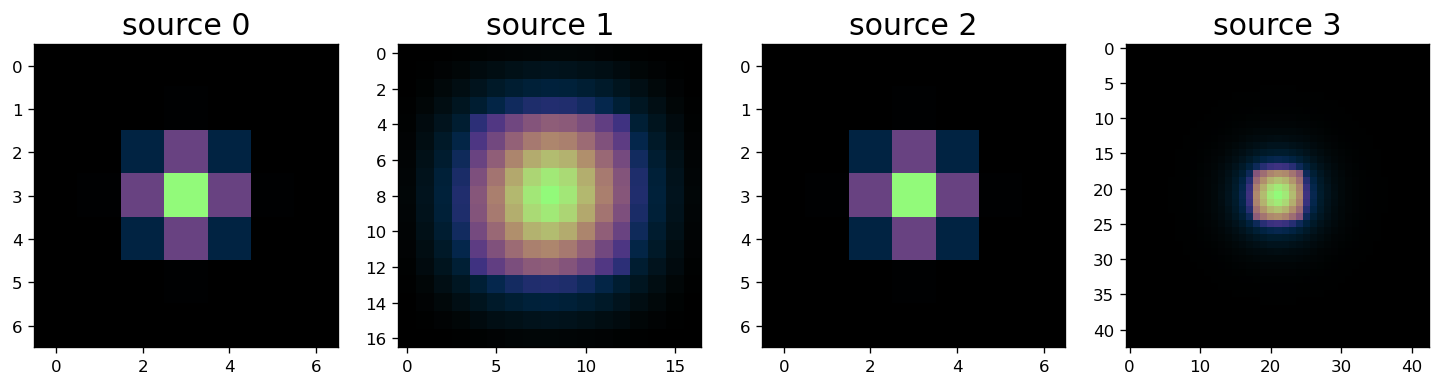

<Figure size 640x480 with 0 Axes>

In [22]:
import cmasher as cmr
cmap = cmr.lilac
int_method='none'
fig, axes = plt.subplots(1, len( scene.sources ), figsize=(15,6),dpi=120)
for i, ax in enumerate(axes):
    if True:#i!=indtransient:
        y = scene.sources[i].morphology()#[0]
    else:
        y = scene.sources[i].morphology.data
    ax.imshow(y, cmap = cmap,interpolation=int_method)#,vmin = np.max([np.min(np.log(y)[np.log(y)>-15]),-15]))
    ax.set_title(f"source {i}", fontsize = 18)
    ax.invert_yaxis()
plt.show()
plt.clf()

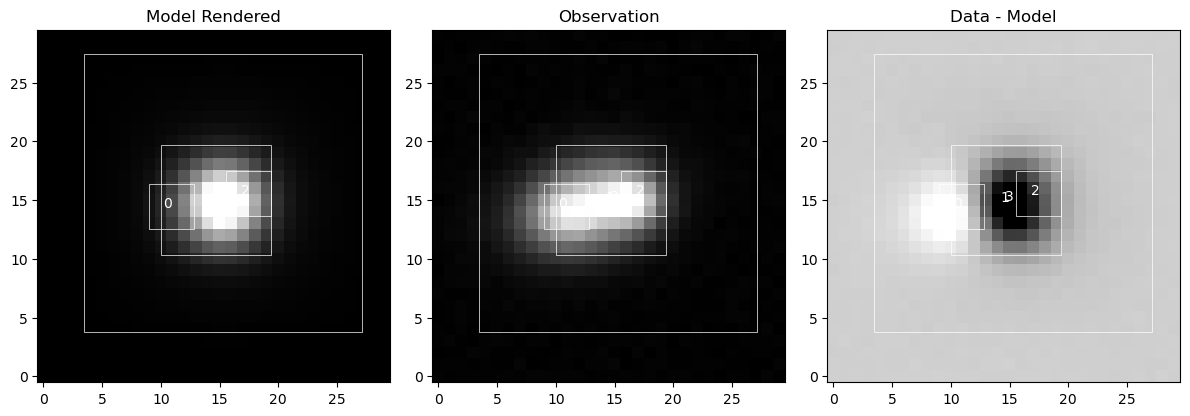

In [23]:
#print(obs_hsc.data.shape,obs_hst.data.shape)
#print(frameall.channels,channels_zeroed)
#print(obs_hsc.render(scene()).shape,obs_hst.render(scene()).shape)
scarlet2.plot.scene(
    scene,
    observation=observations_sc2[11],
    norm=None,#normsingle[0],
    channel_map=None,
    show_model=False,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True
)
plt.show()

### Fitting

In [24]:
pos_step = 1e-3
morph_step = lambda p: scarlet2.relative_step(p, factor=1e-3)
SED_step = lambda p: scarlet2.relative_step(p, factor=5e-4)  #factor=1e-3 or 1e-5

parameters = scene.make_parameters()

for source_indx in range(len(scene.sources)):

    print(source_indx)
    
    parameters += scarlet2.Parameter(scene.sources[source_indx].spectrum.data, 
                                     name=f"spectrum.{source_indx}", 
                                     constraint=constraints.positive, stepsize=SED_step
                                    )   #are constrains supposed to be included? no in scarlet2 docs

    if is_extended[source_indx]:
        #Static host galaxy parameters; or lens
        parameters += scarlet2.Parameter(scene.sources[source_indx].morphology.coeffs, #morphology.data or morphology.coeffs
                                         name=f"morph.{source_indx}", stepsize=morph_step
                                        )#, prior=prior)
        
    else:
        #Transient point source parameters
        parameters += scarlet2.Parameter(scene.sources[source_indx].center, 
                                         name=f"center.{source_indx}", 
                                         constraint=constraints.positive, stepsize=pos_step
                                        )
         
    
        

0
Error processing fieldname 'node'. - __cuda_array_interface__ is only defined for NVidia GPU buffers.
Error processing fieldname 'node'. - descriptor '__weakref__' for 'Array' objects doesn't apply to a 'jaxlib._jax.ArrayImpl' object
Error processing fieldname 'node'. - arr.device_buffer has been deprecated. Use arr.addressable_data(0)
Error processing fieldname 'node'. - arr.device_buffers has been deprecated. Use [x.data for x in arr.addressable_shards]
Error processing fieldname 'node'. - JAX Arrays do not implement the arr.flat property: consider arr.flatten() instead.
Error processing fieldname 'node'. - x must be at least two-dimensional for matrix_transpose; got ndim=1
Error processing fieldname 'node'. - __cuda_array_interface__ is only defined for NVidia GPU buffers.
Error processing fieldname 'node'. - descriptor '__weakref__' for 'Array' objects doesn't apply to a 'jaxlib._jax.ArrayImpl' object
Error processing fieldname 'node'. - arr.device_buffer has been deprecated. Use

In [25]:
# Fit the scene
stepnum = 2000
scene_ = scene.fit(observations_sc2, parameters, max_iter=stepnum, e_rel=1e-4, progress_bar=True)

100%|██████████| 2000/2000 [23:31<00:00,  1.42it/s, loss=258791.77, max_change=0.000392]  


In [26]:
print("----------------- {}".format(channels))
for k, src in enumerate(scene_.sources):
    print("Source {}, Fluxes: {}".format(k, scarlet2.measure.flux(src)))

----------------- [('g', '0'), ('g', '1'), ('g', '2'), ('g', '3'), ('g', '4'), ('g', '5'), ('g', '6'), ('g', '7'), ('g', '8'), ('g', '9'), ('g', '10'), ('g', '11'), ('r', '0'), ('r', '1'), ('r', '2'), ('r', '3'), ('r', '4'), ('r', '5'), ('r', '6'), ('r', '7'), ('r', '8'), ('r', '9'), ('r', '10'), ('r', '11'), ('i', '0'), ('i', '1'), ('i', '2'), ('i', '3'), ('i', '4'), ('i', '5'), ('i', '6'), ('i', '7'), ('i', '8'), ('i', '9'), ('i', '10'), ('i', '11'), ('G', '0'), ('R', '0'), ('I', '0'), ('G', '5'), ('R', '5'), ('I', '5')]
Source 0, Fluxes: [1.93888336e+02 1.95009933e+02 1.93298096e+02 1.92943375e+02
 2.12677765e+02 2.24048676e+02 2.18798355e+02 2.18798355e+02
 2.18229553e+02 2.09499985e+02 2.02657333e+02 2.00188156e+02
 4.39447403e+00 3.85596061e+00 3.43387866e+00 4.42784786e+00
 4.86474266e+01 1.07722672e+02 9.60635910e+01 9.60635910e+01
 3.84798317e+01 1.79664516e+01 1.26367579e+01 1.01060715e+01
 7.76149216e+01 7.71445236e+01 7.77280731e+01 7.73944016e+01
 1.13196205e+02 1.51989441

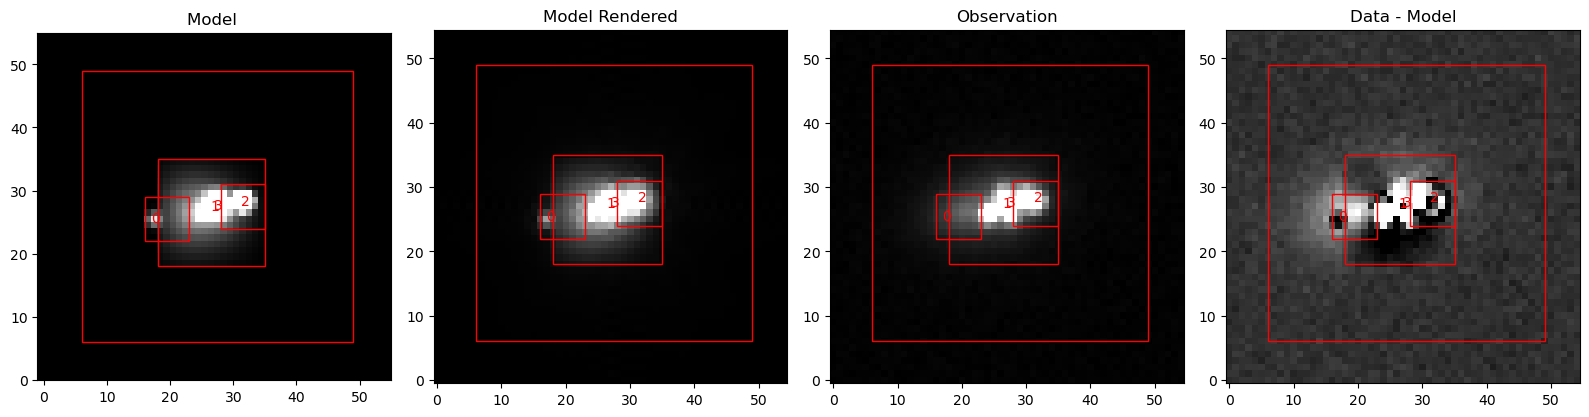

In [27]:
# Plot the model, for each epoch
scarlet2.plot.scene(
    scene_,
    observation=observations_sc2[41],
    norm=None,
    show_model=True,
    show_observed=True,
    show_rendered=True,
    show_residual=True,
    add_labels=True,
    add_boxes=True,
    split_channels=False,
    box_kwargs={"edgecolor": "red", "facecolor": "none"},
    label_kwargs={"color": "red"},
)
plt.show()


In [28]:
## Restructure fluxes into array like lenstronomy structure
# Only Rubin fluxes

#[
#  [  # g-band
#    [flux_source0_epoch0, flux_source1_epoch0, ..., flux_sourceN_epoch0],
#    [flux_source0_epoch1, flux_source1_epoch1, ..., flux_sourceN_epoch1],
#    ...
#  ],

#  [  # r-band
#    [...],
#    ...
#  ],

#  [  # i-band
#    [...],
#    ...
#  ]
#]


In [29]:
import pickle

# Define Rubin bands of interest
rubin_bands = ['g', 'r', 'i']

# Get indices of (band, epoch) for each Rubin band
band_epoch_indices = {band: [] for band in rubin_bands}
for idx, (band, epoch) in enumerate(channels):
    if band in rubin_bands:
        band_epoch_indices[band].append((int(epoch), idx))

# Get indices of point sources (is_extended == False)
point_source_indices = [i for i, ext in enumerate(is_extended) if not ext]
num_point_sources = len(point_source_indices)

# Determine the number of epochs per band
max_epochs = {
    band: max(epoch for epoch, _ in indices) + 1
    for band, indices in band_epoch_indices.items()
}

# Initialize output flux structure: bands × epochs × sources
flux_array = {
    band: [[0.0 for _ in range(num_point_sources)] for _ in range(max_epochs[band])]
    for band in rubin_bands
}

# Fill in the flux values for only point sources
for local_idx, src_idx in enumerate(point_source_indices):
    fluxes = scarlet2.measure.flux(scene_.sources[src_idx])
    for band in rubin_bands:
        for epoch, flux_idx in band_epoch_indices[band]:
            flux_array[band][epoch][local_idx] = fluxes[flux_idx]

# Convert to final nested array format
output_array = [flux_array[band] for band in rubin_bands]

print(output_array)

#Save to file
with open("rubin_scarlet_fluxes.pkl", "wb") as f:
    pickle.dump(output_array, f)


[[[Array(193.88834, dtype=float32), Array(45.042572, dtype=float32)], [Array(195.00993, dtype=float32), Array(46.958874, dtype=float32)], [Array(193.2981, dtype=float32), Array(45.76009, dtype=float32)], [Array(192.94337, dtype=float32), Array(45.954727, dtype=float32)], [Array(212.67776, dtype=float32), Array(76.02968, dtype=float32)], [Array(224.04868, dtype=float32), Array(102.25904, dtype=float32)], [Array(218.79836, dtype=float32), Array(92.16434, dtype=float32)], [Array(218.79836, dtype=float32), Array(92.16434, dtype=float32)], [Array(218.22955, dtype=float32), Array(79.42573, dtype=float32)], [Array(209.49998, dtype=float32), Array(81.14668, dtype=float32)], [Array(202.65733, dtype=float32), Array(63.57633, dtype=float32)], [Array(200.18816, dtype=float32), Array(62.09559, dtype=float32)]], [[Array(4.394474, dtype=float32), Array(27.970428, dtype=float32)], [Array(3.8559606, dtype=float32), Array(27.700533, dtype=float32)], [Array(3.4338787, dtype=float32), Array(27.712425, dty

In [30]:
print("----------------- {}".format(channels))
for k, src in enumerate(scene_.sources):
    print("Source {}, Fluxes: {}".format(k, scarlet2.measure.flux(src)))

----------------- [('g', '0'), ('g', '1'), ('g', '2'), ('g', '3'), ('g', '4'), ('g', '5'), ('g', '6'), ('g', '7'), ('g', '8'), ('g', '9'), ('g', '10'), ('g', '11'), ('r', '0'), ('r', '1'), ('r', '2'), ('r', '3'), ('r', '4'), ('r', '5'), ('r', '6'), ('r', '7'), ('r', '8'), ('r', '9'), ('r', '10'), ('r', '11'), ('i', '0'), ('i', '1'), ('i', '2'), ('i', '3'), ('i', '4'), ('i', '5'), ('i', '6'), ('i', '7'), ('i', '8'), ('i', '9'), ('i', '10'), ('i', '11'), ('G', '0'), ('R', '0'), ('I', '0'), ('G', '5'), ('R', '5'), ('I', '5')]
Source 0, Fluxes: [1.93888336e+02 1.95009933e+02 1.93298096e+02 1.92943375e+02
 2.12677765e+02 2.24048676e+02 2.18798355e+02 2.18798355e+02
 2.18229553e+02 2.09499985e+02 2.02657333e+02 2.00188156e+02
 4.39447403e+00 3.85596061e+00 3.43387866e+00 4.42784786e+00
 4.86474266e+01 1.07722672e+02 9.60635910e+01 9.60635910e+01
 3.84798317e+01 1.79664516e+01 1.26367579e+01 1.01060715e+01
 7.76149216e+01 7.71445236e+01 7.77280731e+01 7.73944016e+01
 1.13196205e+02 1.51989441